In [1]:
import pygmo as pg
import numpy as np
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
location = "bulk"
occupations_old = np.zeros(24)
mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=-1, U=0, delta=0.832, occupations= occupations_old
    )
problem = Problem(
        structure_path=mean_field_problem.structure_path, 
        structure_name=mean_field_problem.structure_name)
mean_field_problem._set_eigenvalues(problem, occupations_old, debug=True)
problem.setup(
    N_r = 10,
    N_k = 200,
    location = location,
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.8319999999999999, 't_pp_pi': -0.16800000000000004, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.8319999999999999, 't_pp_pi': -0.16800000000000004, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'C': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': np.float64(0.0), 'n_px_down': np.float64(0.0), 'n_py_up': np.float64(0.0), 'n_py_down': np.float64(0.0), 'n_pz_up': np.float64(0.0), 'n_pz_down': np.float64(0.0)}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.8319999999999999, 't_pp_pi': -

In [4]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

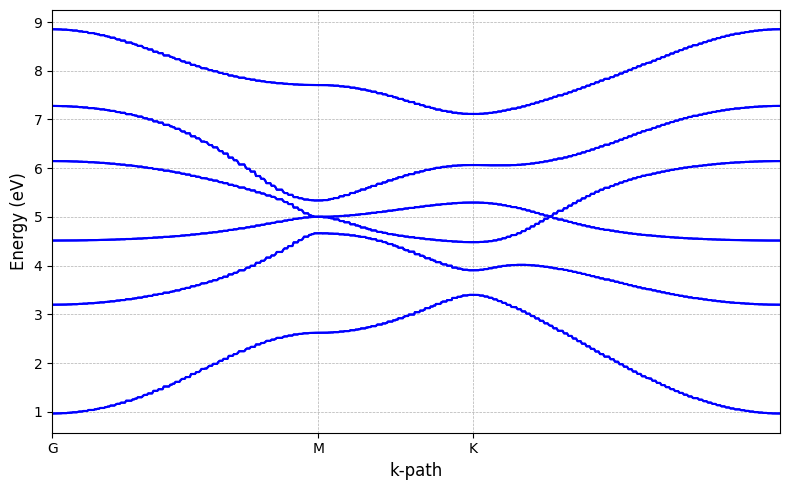

In [5]:
j_3_2 = [i for i in range(8, 24)]
tb_bulk.plot_band_structure(g, bands=j_3_2)

In [6]:
mean_field_problem.setup(11, 1, 0.05, T = 300, N_h = 2)

In [7]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)

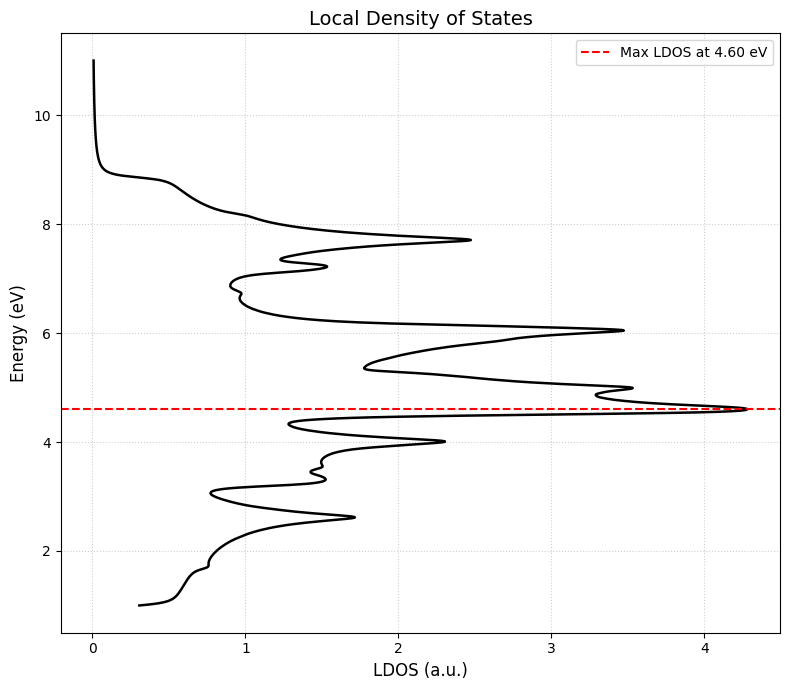

In [8]:
invariants.plot_density_of_states(E, DOS)

In [12]:
U = 3
N_h = 3
location = "bulk"
tol = 1e-4
occupations_old = np.zeros(24)
converged_e, converged_h = False, False
counter = 0
results = {}
while not converged_e:
    mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=-1, U=U, delta=0.832, occupations= occupations_old
    )
    mean_field_problem.setup(10, -10, 0.05, T = 300, N_h = N_h)
    problem = Problem(
            structure_path=mean_field_problem.structure_path, 
            structure_name=mean_field_problem.structure_name)
    mean_field_problem._set_eigenvalues(problem, occupations_old)
    problem.setup(
        N_r = 10,
        N_k = 200,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    g = problem.geometry
    tb_bulk = problem.hamiltonian[location]["tight_binding"]
    invariants = problem.hamiltonian["bulk"]["topological_invariants"]
    E, DOS = mean_field_problem.density_of_states(
        g, tb_bulk, invariants, mean_field_problem.E_max, 
        mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)
    mu_max = np.max(E) + 10
    mu_min = np.min(E) - 10
    mu = mean_field_problem.find_chemical_potential(
        E, DOS, mean_field_problem.N_h, mean_field_problem.T, 
        mu_max, mu_min
    )
    occ_e, occ_h = mean_field_problem.get_occupations(
        g, tb_bulk, E, mu, mean_field_problem.T
        )
    results[counter] = occ_e
    diff_e = np.abs(occupations_old - occ_e)
    converged_e = np.all(diff_e < tol)
    diff_h = np.abs(np.sum(occ_h) -N_h)
    converged_h =  np.all(diff_h < tol)
    print(counter, diff_h, diff_e)
    occupations_old = occ_e
    counter +=1

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/mean_field_problem.py:113: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((E - mu)*beta) + 1.0)


0 0.06979312337827537 [1.         1.         0.5884629  0.5884629  0.66583281 0.66583281
 0.82648147 0.82648147 1.         1.         0.5884629  0.5884629
 0.66583281 0.66583281 0.82648147 0.82648147 1.         1.
 0.70467695 0.70470407 0.5494661  0.54949322 0.82651558 0.82648846]
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 0.12320841636303026 [1.         1.         0.18610461 0.18610483 0.2011984  0.20119655
 0.20885578 0.20885875 1.         1.         0.18610461 0.18610483
 0.2011984  0.20119655 0.20885578 0.20885875 1.         1.
 0.21604503 0.21606148 0.17890724 0.17892832 0.21382632 0.21380816]
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
2 0.1255431298049663 [1.         1.         0.01742917 0.01742969 0.01819312 0.01819243
 0.00265746 0.00265876 1.        

In [10]:
np.savetxt(f"results/occupations_symmetric_U={U}.txt", occ_e)

In [11]:
occ_e

array([1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888])